In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando: {device}")

Usando: cuda


In [2]:
from google.colab import drive
drive.mount('/content/drive')

data_dir  = '/content/drive/MyDrive/landmark_images'
train_dir = os.path.join(data_dir, 'train')
test_dir  = os.path.join(data_dir, 'test')

print(os.listdir(data_dir))

Mounted at /content/drive
['README.md', 'train', 'test']


In [3]:
train_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transformaciones listas")

Transformaciones listas


In [4]:
full_train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)

train_size = int(0.8 * len(full_train_dataset))
val_size   = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])
val_dataset.dataset        = datasets.ImageFolder(train_dir, transform=val_test_transforms)
test_dataset               = datasets.ImageFolder(test_dir,  transform=val_test_transforms)

num_classes = len(full_train_dataset.classes)
class_names = full_train_dataset.classes

batch_size   = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")
print(f"Clases: {num_classes}")

Train: 3996 | Val: 1000 | Test: 1250
Clases: 50


## Justificación del Modelo Preentrenado: ResNet18

Se seleccionó **ResNet18** como modelo preentrenado por las siguientes razones:

1. **Preentrenado en ImageNet**: ResNet18 fue entrenado con más de 1 millón de imágenes
de 1000 categorías distintas. Esto significa que sus capas ya aprendieron a detectar
features visuales útiles como bordes, texturas, formas y patrones complejos —
exactamente lo que necesitamos para reconocer landmarks.

2. **Arquitectura residual**: Sus conexiones residuales (skip connections) evitan el
problema de gradientes que desaparecen, permitiendo un entrenamiento más estable
y eficiente.

3. **Liviano y eficiente**: Comparado con ResNet50 o VGG16, ResNet18 es más rápido
de entrenar manteniendo un buen nivel de accuracy. Ideal para datasets medianos
como este de 50 clases.

4. **Transfer Learning efectivo**: Al congelar las capas del feature extractor y
reemplazar solo la capa final, aprovechamos todo el conocimiento previo del modelo
y solo entrenamos los parámetros necesarios para nuestras 50 clases de landmarks.

**Conclusión**: ResNet18 representa el mejor balance entre rendimiento, velocidad
de entrenamiento y simplicidad de implementación para este proyecto.

In [5]:
# Cargar ResNet18 preentrenado en ImageNet
model_tl = models.resnet18(pretrained=True)

# Congelar todas las capas del feature extractor
for param in model_tl.parameters():
    param.requires_grad = False

# Reemplazar solo la capa final con una nueva para 50 clases
num_features     = model_tl.fc.in_features
model_tl.fc      = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, num_classes)
)

model_tl = model_tl.to(device)
print(f"Modelo ResNet18 listo en: {device}")
print(f"Capa final: {model_tl.fc}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 201MB/s]


Modelo ResNet18 listo en: cuda
Capa final: Sequential(
  (0): Linear(in_features=512, out_features=256, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.4, inplace=False)
  (3): Linear(in_features=256, out_features=50, bias=True)
)


In [6]:
# Solo entrenamos los parámetros de la capa final (los demás están congelados)
criterion_tl = nn.CrossEntropyLoss()
optimizer_tl = torch.optim.Adam(model_tl.fc.parameters(), lr=0.001)

print("Loss y optimizer listos")

Loss y optimizer listos


In [7]:
n_epochs_tl = 20  # con Transfer Learning 20 épocas es suficiente

tl_train_losses = []
tl_val_losses   = []
tl_train_accs   = []
tl_val_accs     = []

best_val_loss_tl = float('inf')

for epoch in range(1, n_epochs_tl + 1):

    # ---- ENTRENAMIENTO ----
    model_tl.train()
    running_loss = 0.0
    correct      = 0
    total        = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer_tl.zero_grad()
        outputs = model_tl(images)
        loss    = criterion_tl(outputs, labels)
        loss.backward()
        optimizer_tl.step()

        running_loss += loss.item() * images.size(0)
        _, predicted  = outputs.max(1)
        correct      += predicted.eq(labels).sum().item()
        total        += labels.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total

    # ---- VALIDACIÓN ----
    model_tl.eval()
    val_running_loss = 0.0
    val_correct      = 0
    val_total        = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs        = model_tl(images)
            loss           = criterion_tl(outputs, labels)

            val_running_loss += loss.item() * images.size(0)
            _, predicted      = outputs.max(1)
            val_correct      += predicted.eq(labels).sum().item()
            val_total        += labels.size(0)

    val_loss = val_running_loss / val_total
    val_acc  = val_correct / val_total

    tl_train_losses.append(train_loss)
    tl_val_losses.append(val_loss)
    tl_train_accs.append(train_acc)
    tl_val_accs.append(val_acc)

    if val_loss < best_val_loss_tl:
        best_val_loss_tl = val_loss
        torch.save(model_tl.state_dict(), 'best_model_tl.pth')
        print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} ⭐ guardado")
    else:
        print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

Epoch 01 | Train Loss: 3.5282 | Val Loss: 2.7433 | Train Acc: 0.1499 | Val Acc: 0.3910 ⭐ guardado
Epoch 02 | Train Loss: 2.5723 | Val Loss: 2.0252 | Train Acc: 0.3669 | Val Acc: 0.5240 ⭐ guardado
Epoch 03 | Train Loss: 2.1255 | Val Loss: 1.7235 | Train Acc: 0.4585 | Val Acc: 0.5920 ⭐ guardado
Epoch 04 | Train Loss: 1.8940 | Val Loss: 1.6049 | Train Acc: 0.5053 | Val Acc: 0.6040 ⭐ guardado
Epoch 05 | Train Loss: 1.7571 | Val Loss: 1.4575 | Train Acc: 0.5413 | Val Acc: 0.6400 ⭐ guardado
Epoch 06 | Train Loss: 1.6555 | Val Loss: 1.4016 | Train Acc: 0.5653 | Val Acc: 0.6340 ⭐ guardado
Epoch 07 | Train Loss: 1.5899 | Val Loss: 1.3368 | Train Acc: 0.5771 | Val Acc: 0.6440 ⭐ guardado
Epoch 08 | Train Loss: 1.5349 | Val Loss: 1.3264 | Train Acc: 0.5913 | Val Acc: 0.6380 ⭐ guardado
Epoch 09 | Train Loss: 1.5057 | Val Loss: 1.3452 | Train Acc: 0.6026 | Val Acc: 0.6610
Epoch 10 | Train Loss: 1.4390 | Val Loss: 1.2603 | Train Acc: 0.6134 | Val Acc: 0.6720 ⭐ guardado
Epoch 11 | Train Loss: 1.4063 |

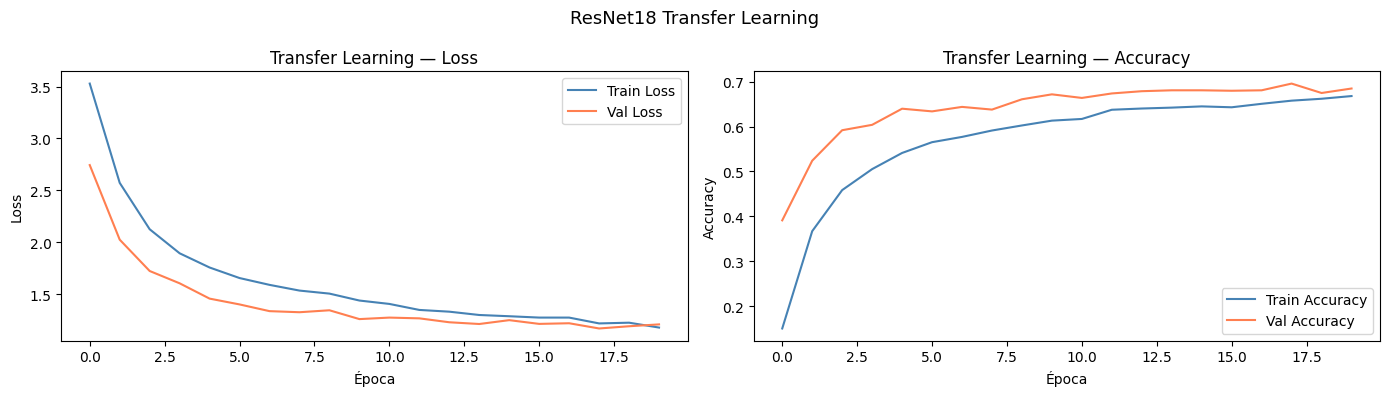

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(tl_train_losses, label='Train Loss', color='steelblue')
axes[0].plot(tl_val_losses,   label='Val Loss',   color='coral')
axes[0].set_title('Transfer Learning — Loss')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(tl_train_accs, label='Train Accuracy', color='steelblue')
axes[1].plot(tl_val_accs,   label='Val Accuracy',   color='coral')
axes[1].set_title('Transfer Learning — Accuracy')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('ResNet18 Transfer Learning', fontsize=13)
plt.tight_layout()
plt.show()

In [9]:
model_tl.load_state_dict(torch.load('best_model_tl.pth'))
model_tl.eval()

test_correct = 0
test_total   = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs        = model_tl(images)
        _, predicted   = outputs.max(1)
        test_correct  += predicted.eq(labels).sum().item()
        test_total    += labels.size(0)

test_acc_tl = test_correct / test_total
print(f"Test Accuracy Transfer Learning: {test_acc_tl:.4f} ({test_acc_tl*100:.2f}%)")

# Exportar con Torch Script
model_tl_cpu    = model_tl.cpu()
scripted_tl     = torch.jit.script(model_tl_cpu)
scripted_tl.save('model_tl_scripted.pt')
print("Modelo exportado con Torch Script")

Test Accuracy Transfer Learning: 0.7136 (71.36%)
Modelo exportado con Torch Script
